***le but du projet est de creer un modele de ML qui accordera ou non du credit***

In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sbn 
import numpy as np
#% matplotlib notebook

## 1. Analyse de Forme
1. indentifiaction du target :  la colonne Loan_Status est la cible(target)
2. nombre de ligne et colonne : le dataset contient 614 lignes et 13 colonnes
4. les differents type present: il y'a 8 object, 4 float ey 1 int.
3. les valeurs manquantes: il ya tres peu des valeurs manquantes dans le dataset. C'est un bn remarque pour faire du fillna 

In [2]:
databank=pd.read_csv('train_bank.csv')
databank

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [3]:
#sbn.boxplot(x='Loan_Status',y='ApplicantIncome',data=databank)
print('le dataset contient {} lignes et {} colonnes'.format(databank.shape[0],databank.shape[1]))
#les valeurs manquantes
databank.isna().sum(axis=0)

le dataset contient 614 lignes et 13 colonnes


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [4]:
#sbn.heatmap(databank.isna(),)
#pd.crosstab(databank['Loan_Status'],databank['Credit_History'])
databank.dtypes.value_counts()

object     8
float64    4
int64      1
Name: count, dtype: int64

## 2. Analyse du fond
1. visualiation du target: on est en presence d'un classe desequilibée, il y'a environ 70% de oui et 30% de non .
2. comprehension des differentes variables: les varaibles contunes:#on voit que CoapplicantIncome suit une loi distribution expodentielle, le montant du pret suit une distribution positive assymetrique, tres eu des personnes prennent un montant > a 200. le terme de remboursement suit une distribution non normale avec un long terme de reboursement.
3. relation target- variable:
  - target - varaible continue:
  - target / discret:
  - target/ objet:
  

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

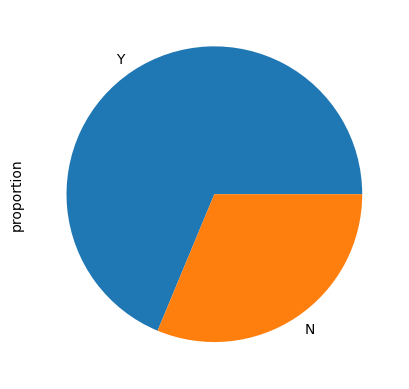

In [5]:
# visualisation du target
(databank.iloc[:,-1].value_counts(normalize=True)*100).plot.pie()
databank.iloc[:,-1].value_counts(normalize=True)*100 # pourcentage de chaque categorie

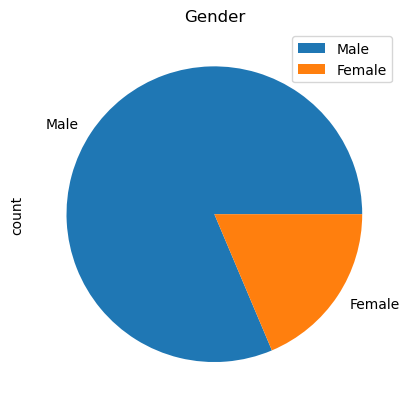

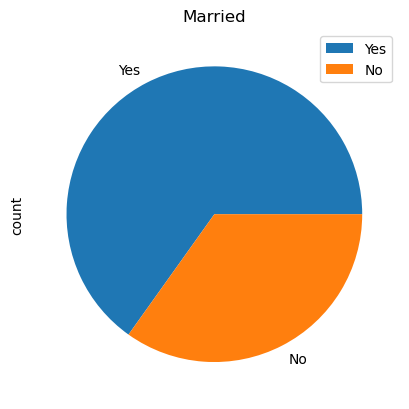

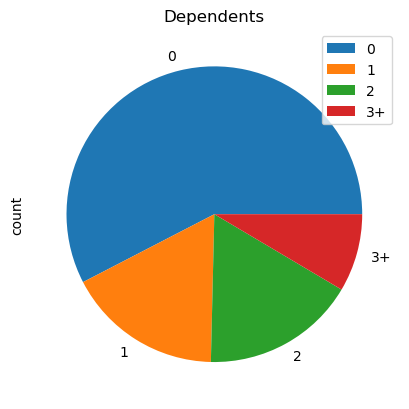

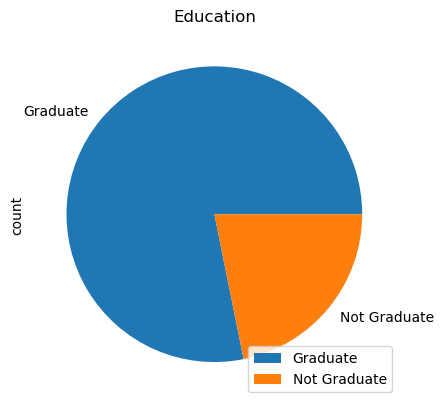

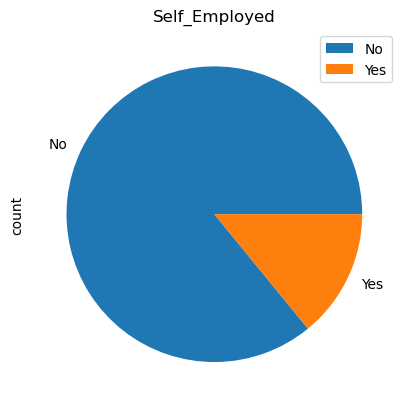

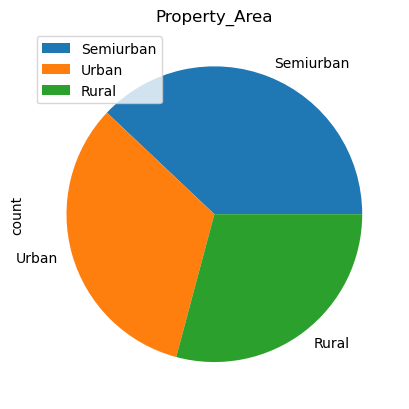

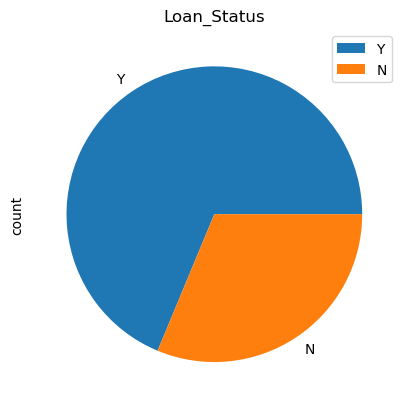

In [6]:
#comprehension des differentes varaibles presentent dans le dataset.
for colonne in databank.select_dtypes('object'):
    if colonne=='Loan_ID':
        continue
    plt.figure()
    plt.title(colonne)
    databank.loc[:,colonne].value_counts().plot.pie()
    plt.legend()
    #print(colonne)

In [7]:
 databank.select_dtypes('object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Y
4,LP001008,Male,No,0,Graduate,No,Urban,Y
...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,Urban,Y


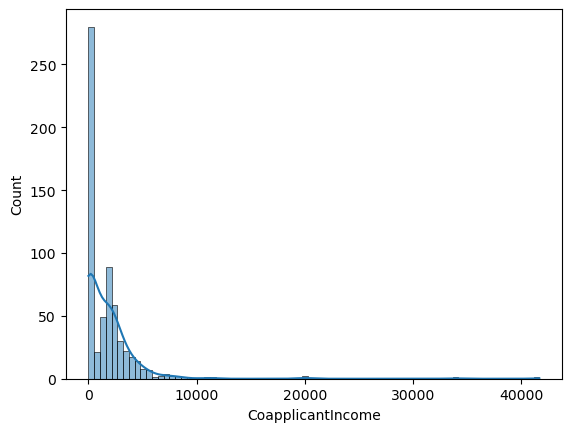

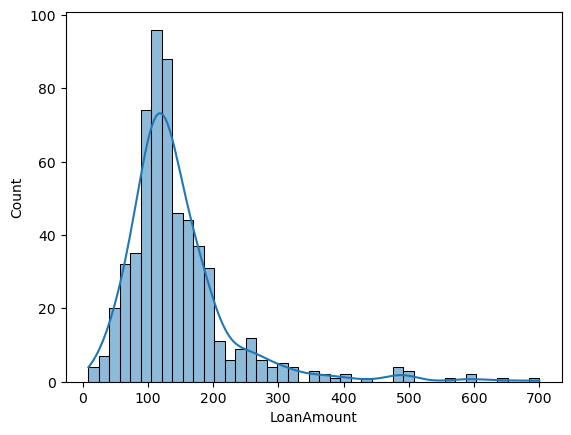

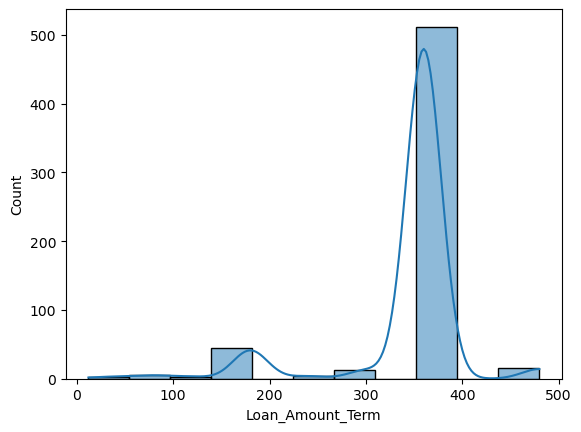

<Figure size 640x480 with 0 Axes>

In [8]:
for i in databank.select_dtypes('float'):
    plt.figure()
    if i!='Credit_History':
        sbn.histplot(databank[i],kde=True)
        
#on voit que CoapplicantIncome suit une loi distribution expodentielle, le montant du pret suit une distribution positive
#assymetrique, tres eu des personnes prennent un montant > a 200. le terme de remboursement suit une distribution non 
# normale avec un long terme de reboursement.

In [9]:
(databank.LoanAmount).mean(),(databank.LoanAmount).median()

(146.41216216216216, 128.0)

<Axes: xlabel='ApplicantIncome', ylabel='Count'>

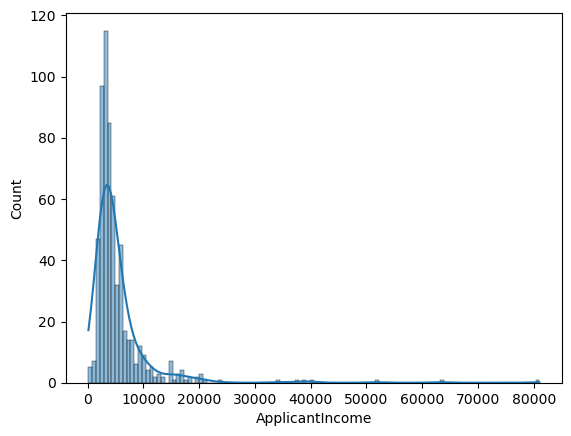

In [10]:
sbn.histplot(x=databank.ApplicantIncome,kde='Density')

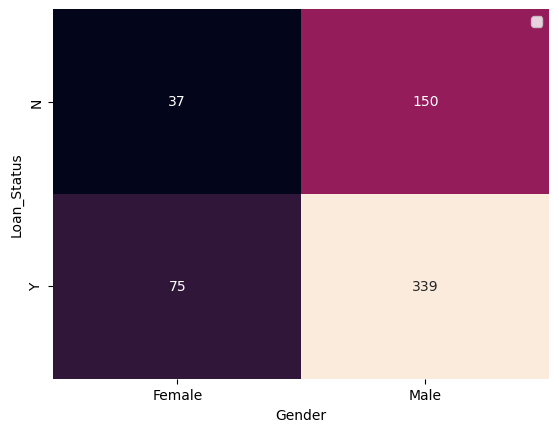

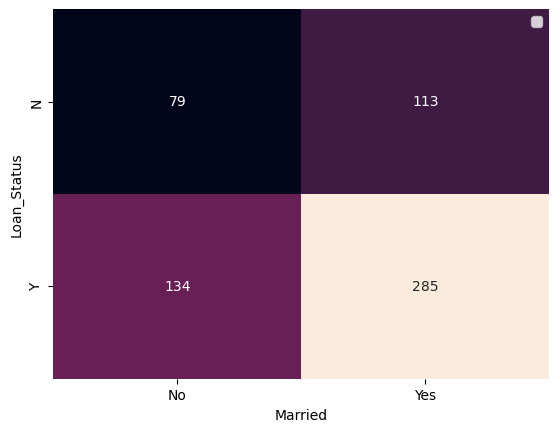

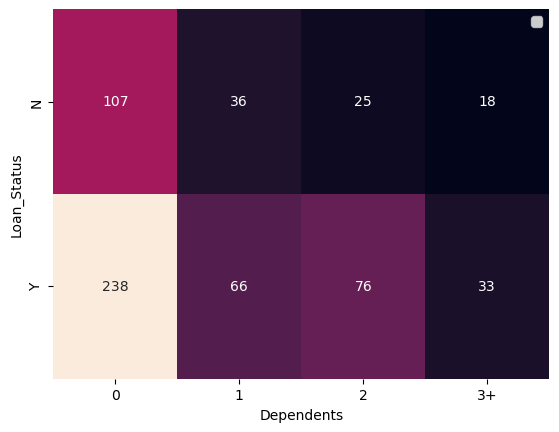

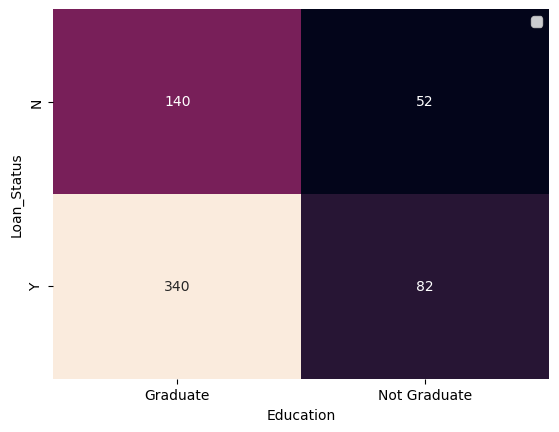

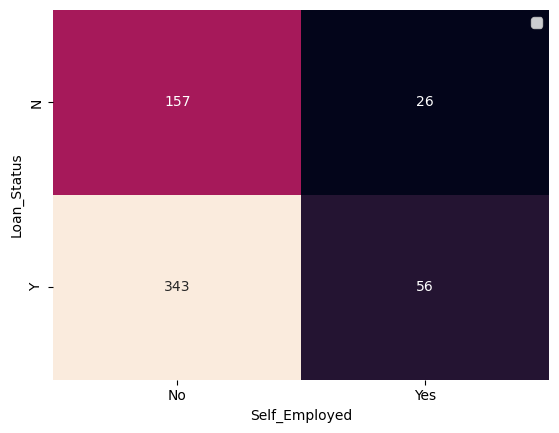

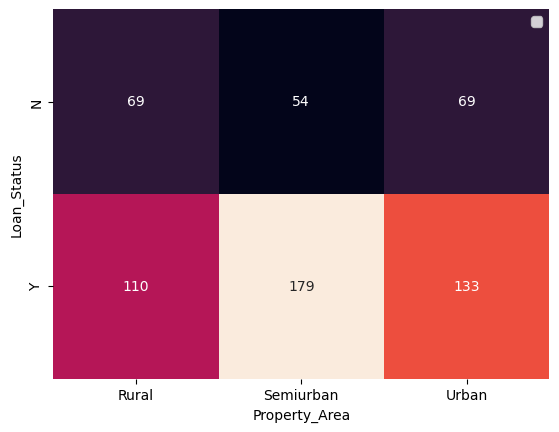

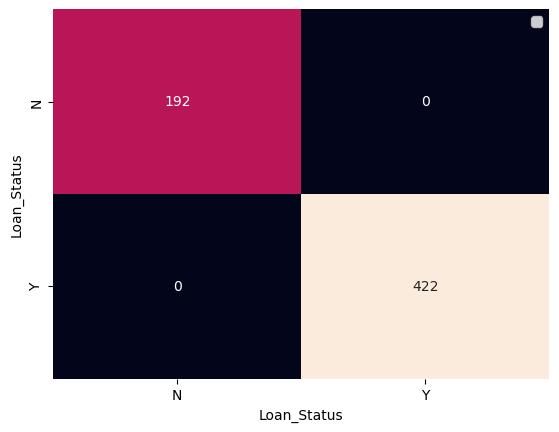

In [11]:
#pd.concat((status_yes.Education,status_no.Education),axis=1)
#utlisons un crosstab pour visualiser les categories enbles
for colonne in databank.select_dtypes('object'):
    if colonne=='Loan_ID':
        continue
    plt.figure()
    sbn.heatmap(pd.crosstab(databank.iloc[:,-1],databank.loc[:,colonne]),cbar=False,annot=True,fmt='d')
    plt.legend(colonne)
    #d'apres l'observation des resultats on ne distingue pas clairement une variable qui permet grace a la quellle un 
    #credit est accorder ou pas.

<Axes: xlabel='Credit_History', ylabel='Loan_Status'>

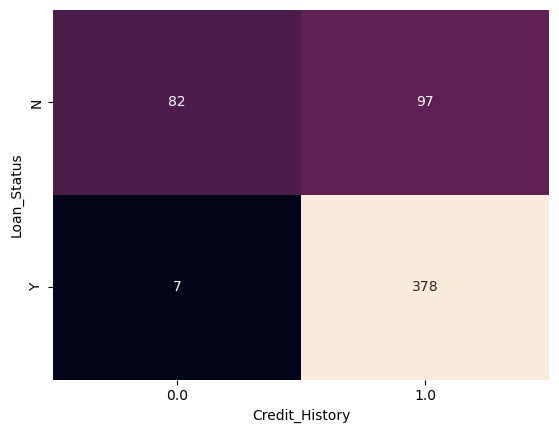

In [12]:
sbn.heatmap(pd.crosstab(databank.Loan_Status,databank.Credit_History),cbar=False,annot=True,fmt='d')
#on voie que la variable historical credit est tres important pour le resultat de la demande de credit. hypothese à verfirr
#c'est un peu bizzqre mais on vit clairement que la banque accorde plus de credit aux personnes ayant deja une credit 

In [13]:
databank['Credit_History'].value_counts()

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

In [14]:
#creeons deux sous ensemble
status_yes=databank[databank.iloc[:,-1]=='Y']# les personnes à qui on a  acceptèe 
status_no=databank[databank.iloc[:,-1]=='N']# les personnes à qui on a  refusèe 
status_yes

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y


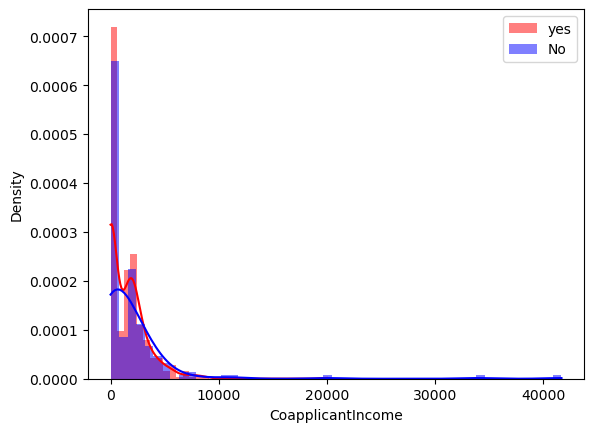

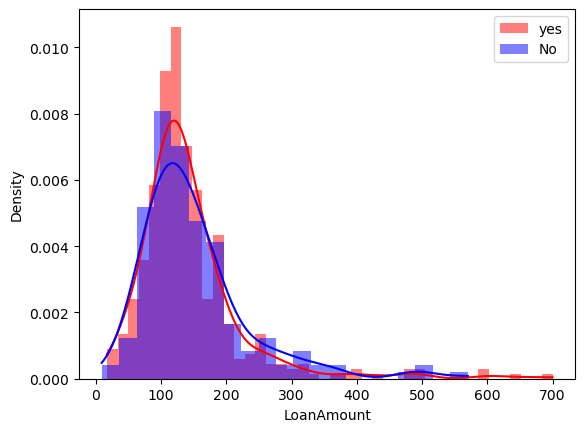

In [15]:
#visualisons la realtion target continue.
for col in databank.select_dtypes('float'):
    if((col!='Credit_History' ) & (col!='Loan_Amount_Term') ):
        plt.figure()
        sbn.histplot(x=col, data=status_yes,kde=True,stat="density", linewidth=0,label='yes',color='r')
        sbn.histplot(x=col, data=status_no,kde=True,stat="density", linewidth=0,label='No',color='b')
        plt.legend()

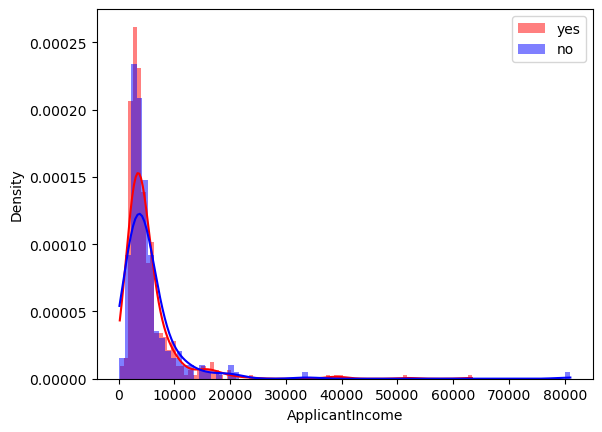

In [16]:
plt.figure()
sbn.histplot(x='ApplicantIncome', data=status_yes,kde=True,stat="density", linewidth=0,label='yes',color='r')
sbn.histplot(x='ApplicantIncome', data=status_no,kde=True,stat="density", linewidth=0,label='no',color='b')
plt.legend()

<Figure size 640x480 with 0 Axes>

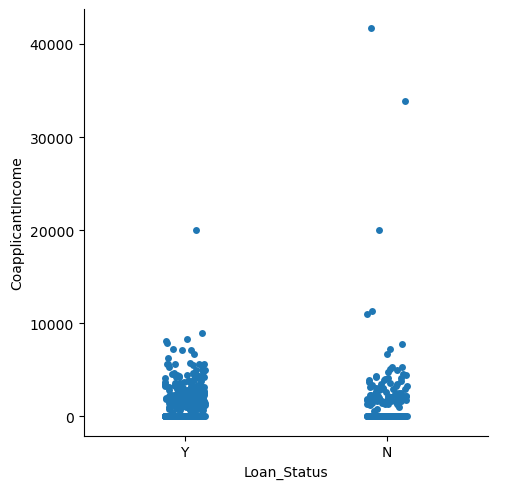

<Figure size 640x480 with 0 Axes>

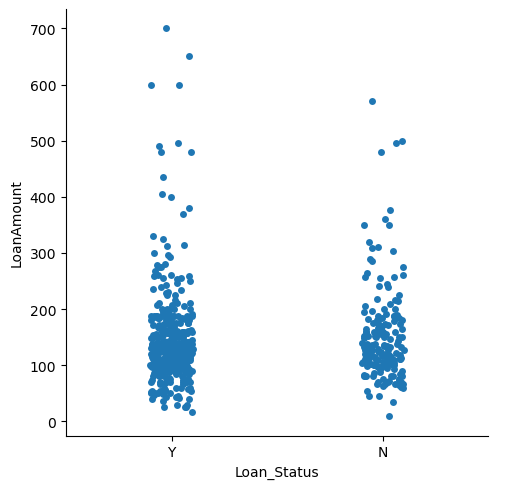

In [17]:
#visualisons la realtion target continue.
for col in databank.select_dtypes('float'):
    if((col!='Credit_History' ) & (col!='Loan_Amount_Term') ):
        plt.figure()
        sbn.catplot(x='Loan_Status',y=col, data=databank)

# Analyse plus detaillée

In [18]:
databank.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

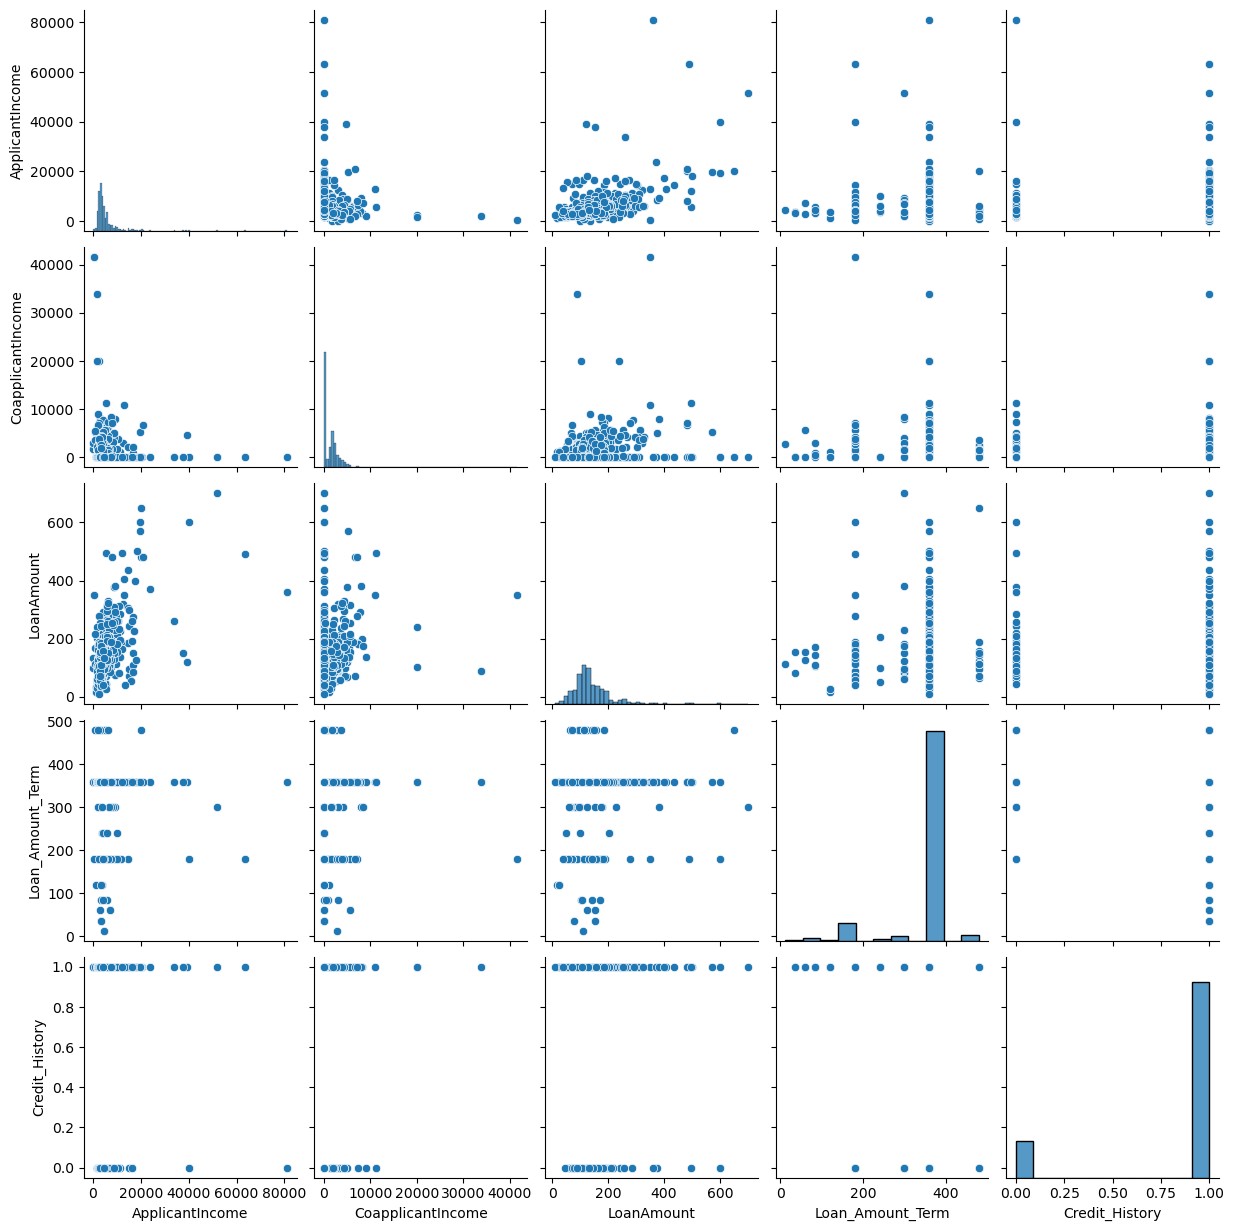

In [19]:
sbn.pairplot(databank)

In [20]:
databank.corr(numeric_only=True)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.570909,-0.045306,-0.014715
CoapplicantIncome,-0.116605,1.000000,0.188619,-0.059878,-0.002056
LoanAmount,0.570909,0.188619,1.000000,0.039447,-0.008433
Loan_Amount_Term,-0.045306,-0.059878,0.039447,1.000000,0.001470
Credit_History,-0.014715,-0.002056,-0.008433,0.001470,1.000000


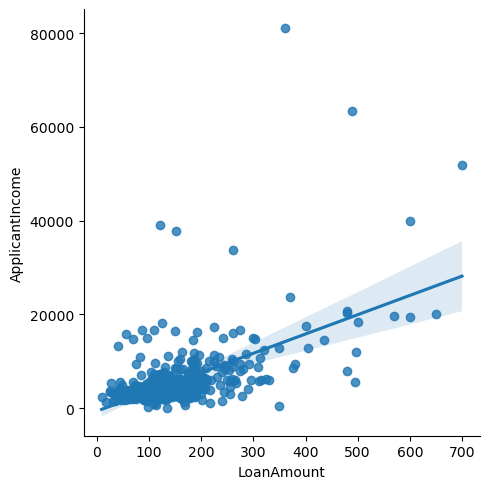

In [21]:
sbn.lmplot(x='LoanAmount',y='ApplicantIncome',data=databank)
#on voit qu'il ya une correlation entre LoanAmount'/ApplicantIncome

In [22]:
status_yes.isna().sum()

Loan_ID               0
Gender                8
Married               3
Dependents            9
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           11
Loan_Amount_Term      8
Credit_History       37
Property_Area         0
Loan_Status           0
dtype: int64

In [23]:
databank.dropna(axis=0)['Loan_Status'].value_counts(normalize=True)
# la prorportion ne change pas apres la suppression  de certain valeur

Loan_Status
Y    0.691667
N    0.308333
Name: proportion, dtype: float64

In [24]:
databank.count()

Loan_ID              614
Gender               601
Married              611
Dependents           599
Education            614
Self_Employed        582
ApplicantIncome      614
CoapplicantIncome    614
LoanAmount           592
Loan_Amount_Term     600
Credit_History       564
Property_Area        614
Loan_Status          614
dtype: int64

# teste d'hypothese.
utilisons le teste de dependance entre deux variable catedorielle (chi2)
1. h0: les deux variables  sont independant
2. hi: les deux sont liee

le lien: [lire teste d'independance](https://datascientest.com/correlation-entre-variables-comment-mesurer-la-dependance)

# v de cramer 

permet mesurer le niveau de corrélation entre les deux variables categorielles.
[lien vers la video](https://www.youtube.com/watch?v=tu9l0GHqrQo&ab_channel=MathHands-OnwithPython)

[lien explicatif](https://www.statology.org/cramers-v-in-python/)

In [25]:
from sklearn.feature_selection import chi2
from scipy.stats import chi2_contingency

def teste_independance(dataframe):
    #une liste contenant tte les colonne object
    liste_object=list(dataframe.select_dtypes('object').columns)[1:-1]
    for col in liste_object:
        tableau_de_contingence=pd.crosstab(databank.iloc[:,-1],databank.loc[:,col])
        resultat=chi2_contingency(tableau_de_contingence)
        p=0.05
        if resultat[1] < p:
            print('pour la colonne {}, H0 est rejetee'.format(col))#Ho les 2 variables sont independants
        else :
            print ('pour la colonne {}, H0 est verifiee'.format(col))
            
teste_independance(databank)

pour la colonne Gender, H0 est verifiee
pour la colonne Married, H0 est rejetee
pour la colonne Dependents, H0 est verifiee
pour la colonne Education, H0 est rejetee
pour la colonne Self_Employed, H0 est verifiee
pour la colonne Property_Area, H0 est rejetee


In [26]:
tableau_de_contingence=pd.crosstab(databank.iloc[:,-1],databank.iloc[:,-3])
chi2_contingency(tableau_de_contingence)

Chi2ContingencyResult(statistic=174.63729658142535, pvalue=7.184759548750746e-40, dof=1, expected_freq=array([[ 28.2464539, 150.7535461],
       [ 60.7535461, 324.2464539]]))

In [27]:
# import researchpy as rp
#pd.crosstab(atabank.iloc[:,-1],databank.iloc[:,-3],margins=False)
#load necessary packages and functions
def V_Cramer(dataframe):
    #une liste contenant tte les colonne object
    liste_object=list(dataframe.select_dtypes('object').columns)[1:-1] + ['Credit_History']
    for col in liste_object:
        #create 2x2 table
        tableau_de_contingence=pd.crosstab(databank.iloc[:,-1],databank.loc[:,col]).to_numpy()
        #Chi-squared test statistic, sample size, and minimum of rows and columns
        x2=chi2_contingency(tableau_de_contingence,correction=False)[0]
        #X2 = stats.chi2_contingency(data, correction=False)[0]
        n = np.sum(tableau_de_contingence)
        minDim = min(tableau_de_contingence.shape)-1
        #calculate Cramer's V 
        V = np.sqrt((x2/n) / minDim)
        #display Cramer's V
        status=list(databank.columns)[-1]
        print(f'la correlation entre la colonne {col} et la colonne {status} est de {V}')
        
V_Cramer(databank)
#coe on a remarquer lors de l'anslyse,il y'a une correlation entre Losn_Status et Credit_History
# la moins correlee avec le target est le Self_Employed

la correlation entre la colonne Gender et la colonne Loan_Status est de 0.019857021688307108
la correlation entre la colonne Married et la colonne Loan_Status est de 0.08928022381335697
la correlation entre la colonne Dependents et la colonne Loan_Status est de 0.07261327309944188
la correlation entre la colonne Education et la colonne Loan_Status est de 0.08588391467536527
la correlation entre la colonne Self_Employed et la colonne Loan_Status est de 0.002302855162865064
la correlation entre la colonne Property_Area et la colonne Loan_Status est de 0.14152279733991546
la correlation entre la colonne Credit_History et la colonne Loan_Status est de 0.5616781574653796


In [28]:
databank.iloc[:,-3].dropna().map((lambda x: int(x))).astype('category')

0      1
1      1
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Credit_History, Length: 564, dtype: category
Categories (2, int64): [0, 1]

In [29]:
pd.get_dummies(databank[['Gender','Education','Credit_History','Loan_Status']])

,Credit_History,Gender_Female,Gender_Male,Education_Graduate,Education_Not Graduate,Loan_Status_N,Loan_Status_Y
0,1.0,False,True,True,False,False,True
1,1.0,False,True,True,False,True,False
2,1.0,False,True,True,False,False,True
3,1.0,False,True,False,True,False,True
4,1.0,False,True,True,False,False,True
...,...,...,...,...,...,...,...
609,1.0,True,False,True,False,False,True
610,1.0,False,True,True,False,False,True
611,1.0,False,True,True,False,False,True
612,1.0,False,True,True,False,False,True


# teste entre une variable cat et continue
test d'Anova . qui permet de verifier si la moyenne entre les different groupes sont egaux.

In [30]:
from sklearn.feature_selection import f_classif,chi2
#print(chi2(databank['ApplicantIncome'].reshape(-1,1),databank['LoanAmount'].reshape(-1,1)))
f_classif(databank['CoapplicantIncome'].to_numpy().reshape(-1,1),databank.iloc[:,-1])
#pd.crosstab(databank.iloc[:,-1],databank.iloc[:,-3]).to_numpy()

(array([2.15145736]), array([0.14294829]))

In [31]:
databank['CoapplicantIncome'][databank.iloc[:,-1]=='N'].std()/databank['CoapplicantIncome'][databank.iloc[:,-1]=='Y'].std()

2.2777238828293638

In [32]:
databank['CoapplicantIncome'][databank.iloc[:,-1]=='Y']

0         0.0
2         0.0
3      2358.0
4         0.0
5      4196.0
        ...  
608    1950.0
609       0.0
610       0.0
611     240.0
612       0.0
Name: CoapplicantIncome, Length: 422, dtype: float64

In [33]:
databank[['Gender','Credit_History','Loan_Status']].groupby(['Gender','Loan_Status']).sum()

Credit_History
Gender Loan_Status                
Female N                      20.0
       Y                      64.0
Male   N                      75.0
       Y                     307.0

In [34]:
#!pip install researchpy

In [35]:
import researchpy as rs
rs.crosstab(databank['Gender'],databank['Loan_Status'],test='chi-square',)

C:\Users\User\anaconda3\Lib\site-packages\researchpy\crosstab.py:146: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Pearson Chi-square ( 1.0) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = f"Pearson Chi-square ({dof: .1f}) = "


(            Loan_Status          
 Loan_Status           N    Y  All
 Gender                           
 Female               37   75  112
 Male                150  339  489
 All                 187  414  601,
                 Chi-square test  results
 0  Pearson Chi-square ( 1.0) =    0.2370
 1                    p-value =    0.6264
 2               Cramer's phi =    0.0199)

In [36]:
rs.crosstab(databank['Loan_Status'],databank['Credit_History'],test='chi-square',)

C:\Users\User\anaconda3\Lib\site-packages\researchpy\crosstab.py:146: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Pearson Chi-square ( 1.0) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = f"Pearson Chi-square ({dof: .1f}) = "


(               Credit_History          
 Credit_History            0.0  1.0  All
 Loan_Status                            
 N                          82   97  179
 Y                           7  378  385
 All                        89  475  564,
                 Chi-square test   results
 0  Pearson Chi-square ( 1.0) =   177.9320
 1                    p-value =     0.0000
 2               Cramer's phi =     0.5617)

In [37]:
data=databank.copy()

# Le Preproccessing 


In [38]:
data= databank.copy()
#supprimons la colonne ID
data.drop(columns='Loan_ID',axis=0,inplace=True)
data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [39]:
# fonction d'encodage 
def encodage(dataframe):
    dictionnaire={'Male':0,'Female':1,'No':0,'Yes':1,'Graduate':1,'Not':0,'Urban':0,'Rural':1,'Semiurban':2,'Y':1,'N':0}
    for col in dataframe.select_dtypes('object'):
        #if col=='Dependents':
        #dataframe[col]=dataframe[col].astype('category').cat.codes
        
        #dataframe[col]=dataframe[col].map(dictionnaire)
        dataframe[col]=dataframe[col].astype('category').cat.codes
    return dataframe
encodage(data)
#for col in data.select_dtypes('object'):
#    print(col)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,NaN,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,0,1
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,0,1
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,2,1
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,2,1


In [40]:
# la Fonction D'imputation
def imputation(dataframe):
    dataframe=encodage(dataframe)
    dataframe.dropna(axis=0,inplace=True)
    return dataframe
imputation(data)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
5,1,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,0,1
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,0,1
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,2,1
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,2,1


In [41]:
#data['Gender'].astype('category').cat.codes
def preproccessing(dataframe):
    dataframe=imputation(dataframe)
    x,y=dataframe.drop(columns='Loan_Status'),dataframe['Loan_Status']
    return x,y

x,y=preproccessing(data)
data.dtypes

Gender                  int8
Married                 int8
Dependents              int8
Education               int8
Self_Employed           int8
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area           int8
Loan_Status             int8
dtype: object

In [42]:
from sklearn.model_selection import train_test_split, validation_curve,learning_curve,ShuffleSplit,KFold,StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report,f1_score
from sklearn.neighbors import KNeighborsClassifier
import sklearn
#develloppons differebts model de classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier,LogisticRegression
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
# liste de modele 
dic_modele={}
transformer=RobustScaler()
dic_modele['neighbors']=make_pipeline(transformer,KNeighborsClassifier(n_neighbors=5))
dic_modele['svm_modele']=make_pipeline(transformer,SVC(random_state=0))
dic_modele['Decision_modele']=make_pipeline(transformer,DecisionTreeClassifier(random_state=0))
dic_modele['sgv_modele']=make_pipeline(transformer,SGDClassifier(random_state=0))
dic_modele['Logistic']=make_pipeline(transformer,LogisticRegression(random_state=42,max_iter=1000))
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,train_size=0.8)

def model_Evaluation(model):
    
    model.fit(x_train,y_train)
    model.score(x_train,y_train)
    y_prediction=model.predict(x_test)
    print(y_prediction)
    print(confusion_matrix(y_test,y_prediction))
    print(classification_report(y_test,y_prediction))
    cv=ShuffleSplit(4,train_size=0.8)
    #sklearn.metrics.f1_score
    nombre_pts,trainscore,testscore=learning_curve(model,x_train,y_train,scoring= 'accuracy' ,cv=cv,
                                                   train_sizes=np.linspace(0.1,1,10))
    #print(trainscore)
    plt.figure(figsize=(8,8))
    plt.title('Evolution de score selon la quantite de donnee fournit')
    plt.plot(nombre_pts,trainscore.mean(axis=1),label='trainscore')
    plt.plot(nombre_pts,testscore.mean(axis=1),label='testscore')
    plt.legend()
    plt.show()

neighbors
[0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[[ 9 24]
 [ 5 68]]
              precision    recall  f1-score   support

           0       0.64      0.27      0.38        33
           1       0.74      0.93      0.82        73

    accuracy                           0.73       106
   macro avg       0.69      0.60      0.60       106
weighted avg       0.71      0.73      0.69       106



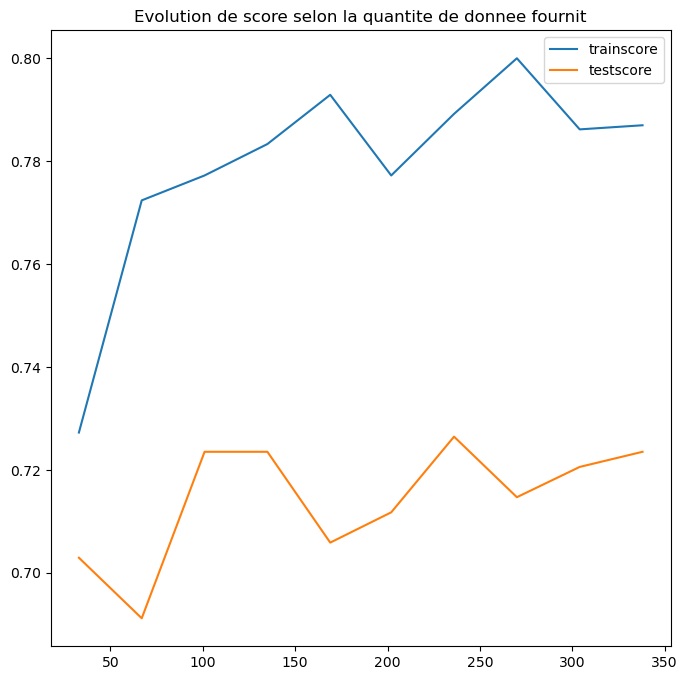

svm_modele
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[[ 2 31]
 [ 3 70]]
              precision    recall  f1-score   support

           0       0.40      0.06      0.11        33
           1       0.69      0.96      0.80        73

    accuracy                           0.68       106
   macro avg       0.55      0.51      0.45       106
weighted avg       0.60      0.68      0.59       106



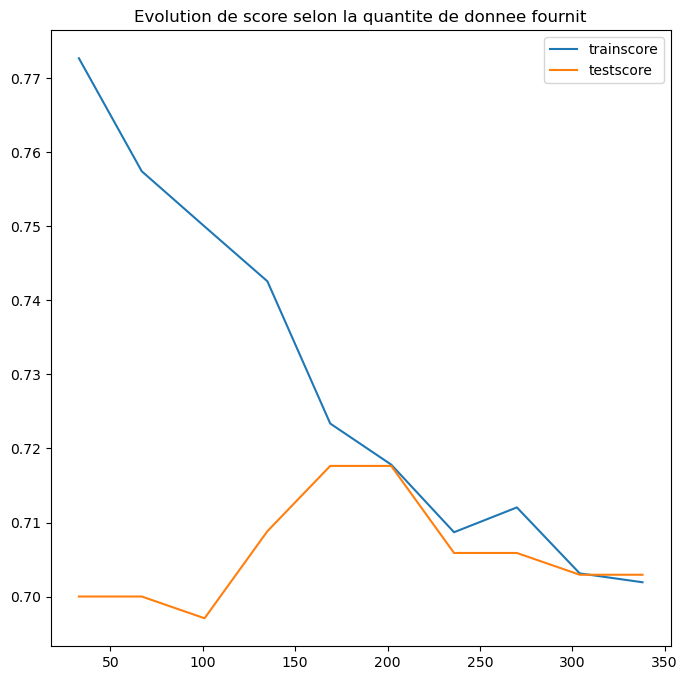

Decision_modele
[0 0 0 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 1 0 1 0 1 1 1 0 0 1 0 1 0 0 1 0 1 1 1 1 0 0 1 1 0 0 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 0 0]
[[18 15]
 [22 51]]
              precision    recall  f1-score   support

           0       0.45      0.55      0.49        33
           1       0.77      0.70      0.73        73

    accuracy                           0.65       106
   macro avg       0.61      0.62      0.61       106
weighted avg       0.67      0.65      0.66       106



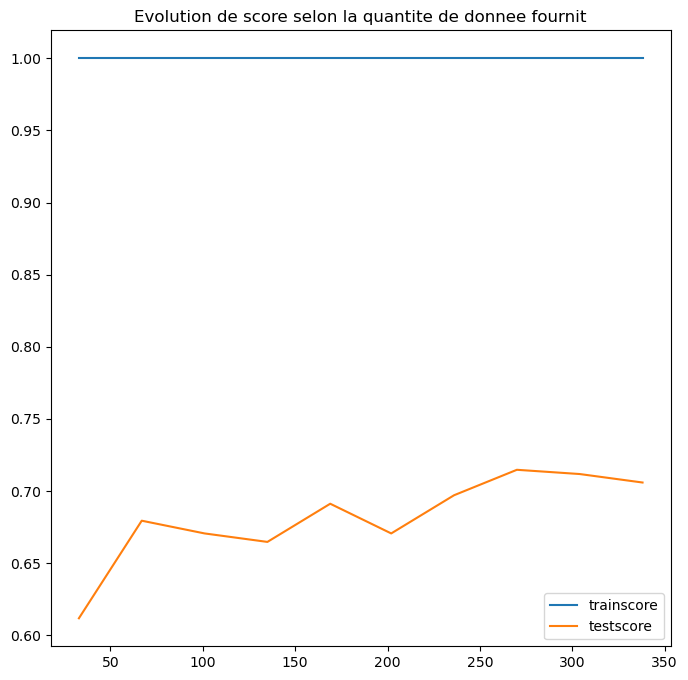

sgv_modele
[0 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 0 1 1 0
 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 1 1 1 0 0 1 0 1 1 0 1 1 1 1 0 0 0 0 1 1
 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1]
[[18 15]
 [10 63]]
              precision    recall  f1-score   support

           0       0.64      0.55      0.59        33
           1       0.81      0.86      0.83        73

    accuracy                           0.76       106
   macro avg       0.73      0.70      0.71       106
weighted avg       0.76      0.76      0.76       106



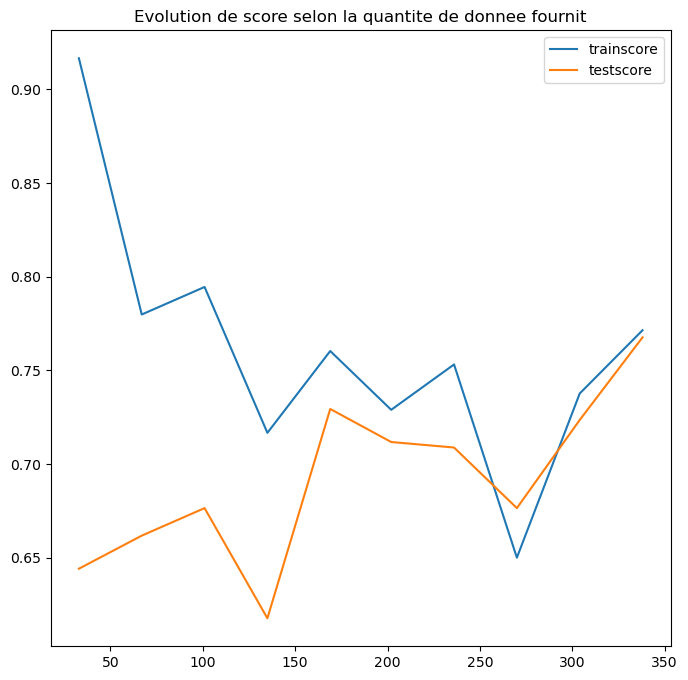

Logistic
[0 0 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 0 1 1 0
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1]
[[16 17]
 [ 1 72]]
              precision    recall  f1-score   support

           0       0.94      0.48      0.64        33
           1       0.81      0.99      0.89        73

    accuracy                           0.83       106
   macro avg       0.88      0.74      0.76       106
weighted avg       0.85      0.83      0.81       106



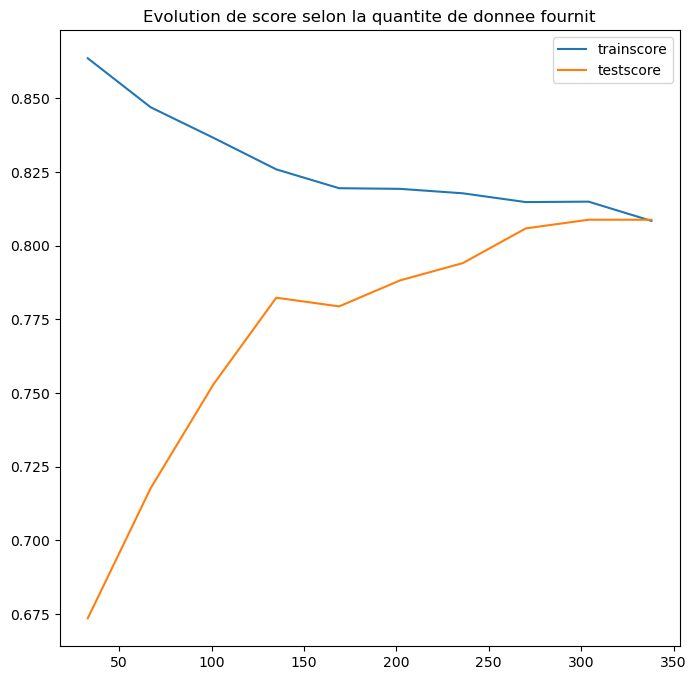

In [43]:
for key,modele in dic_modele.items():
    print(key)
    model_Evaluation(modele)

In [44]:
#sklearn.metrics.SCORERS.keys()
from sklearn.preprocessing import PolynomialFeatures
transformer=PolynomialFeatures(degree=2,include_bias=False)
transformer.fit_transform(x_train).shape

(423, 77)

# Analyse

d'apres le resultat des graphiques on rematrque que le KNK ,SGD et le Logistic  nous donne un bon resultat . pour la suite du projet, nous avons choisit le Logistic car on remarque que le score entre le train et les teste est le plus proche.

In [45]:
data.corr()['Loan_Status']

Gender               0.064047
Married              0.082439
Dependents           0.053927
Education           -0.078434
Self_Employed       -0.060495
ApplicantIncome     -0.006281
CoapplicantIncome   -0.043353
LoanAmount          -0.036642
Loan_Amount_Term    -0.028601
Credit_History       0.547439
Property_Area        0.037287
Loan_Status          1.000000
Name: Loan_Status, dtype: float64

In [46]:
#pip install researchpy  c'est un package qui contient des testes statistique 